# **COVID-19 Detection from Lung CT Scans using Convolutional Neural Networks (CNN)**

This project applies deep learning to classify lung CT scan images into COVID-19 and Non-COVID-19 categories using a Convolutional Neural Network (CNN).

## **Problem Statement**

Early detection of COVID-19 is critical for timely intervention and disease control. While CT scans provide important diagnostic insight, manual review by radiologists can be time-consuming and prone to variability.

This project explores the use of deep learning to automate COVID-19 detection from lung CT scans, improving speed, consistency, and decision support in clinical settings.

## **Objective**

To develop and evaluate a CNN model capable of accurately classifying lung CT scan images into COVID-19 and Non-COVID-19 classes.

## **Data Source**

The dataset used in this project was sourced from Kaggle.

**Dataset:** COVID-19 Lung CT Scans  
**Author:** Mehrad Aria  
**Source URL:** https://www.kaggle.com/datasets/mehradaria/covid19-lung-ct-scans

The dataset contains **8,439 lung CT scan images** collected from real patients in teaching hospitals in Tehran, Iran. The images are provided in **512×512 PNG format** and organized into two classes:

- **COVID-19** (positive cases)
- **Non-COVID-19** (normal and suspicious non-COVID cases)

This dataset was selected because of its large size, clinical relevance, and suitability for supervised deep learning classification tasks.

## **Evaluation Metrics**

In medical classification problems, minimizing false negatives is critical. A false negative means an infected patient is incorrectly classified as healthy, which can delay treatment and increase transmission risk.

For this reason, Recall is treated as the primary evaluation metric.

Additional metrics include:
- Precision: measures reliability of positive predictions
- AUC: measures class separability
- Accuracy: provides overall correctness
- F1-score: balances precision and recall
- Confusion Matrix: visualizes classification errors

## **Library Imports**

The following libraries are used for image preprocessing, model development, visualization, and evaluation.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Recall, Precision, AUC

## **Dataset Preparation**

The dataset consists of two folders:
- COVID-19
- Non-COVID-19

Images are loaded, resized to a uniform dimension of 64x64 pixels, and converted into numerical arrays for model training.

## **Data Preprocessing**

To improve model performance:
- Images were normalized to a pixel range of 0–1.
- Labels were one-hot encoded for binary classification.
- Invalid file types were excluded during ingestion.

In [3]:
IMG_SIZE = 64

data = []
labels = []

categories = ['COVID-19', 'Non-COVID-19']

valid_extensions = ('.png', '.jpg', '.jpeg')

for category in categories:
    
    path = os.path.join(category)
    
    class_num = categories.index(category)

    for img in os.listdir(path):

        if img.lower().endswith(valid_extensions):

            try:
                img_path = os.path.join(path, img)

                img_array = cv2.imread(img_path)

                img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

                data.append(img_array)
                labels.append(class_num)

            except Exception as e:
                print("Error loading:", img)

X = np.array(data)
y = np.array(labels)

X = X.astype('float32') / 255.0

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Images shape: (8439, 64, 64, 3)
Labels shape: (8439,)
Min pixel value: 0.0
Max pixel value: 1.0


## **Dataset Overview**

After preprocessing, the dataset contains 8,439 CT scan images prepared for model development.

## **Data Splitting**

The dataset was split into:
- 70% Training
- 15% Validation
- 15% Testing

This ensures proper model training, tuning, and unbiased evaluation.

In [4]:
y = to_categorical(y, 2)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (5907, 64, 64, 3)
Validation set: (1266, 64, 64, 3)
Testing set: (1266, 64, 64, 3)


## **Sample Image Inspection**

A random sample of CT scan images is visualized to verify image quality, preprocessing consistency, and label correctness.

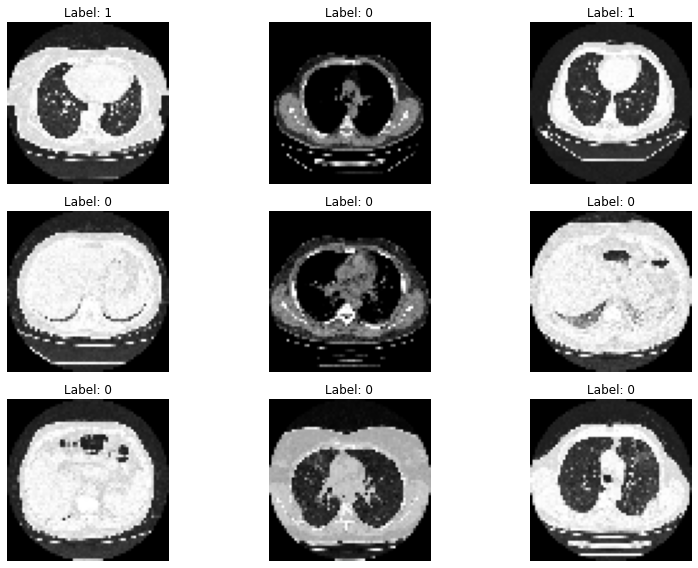

In [5]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Model Architecture**

A Convolutional Neural Network (CNN) was designed to learn spatial patterns in CT scans.

The architecture includes:
- Convolutional layers for feature extraction
- Pooling layers for dimensionality reduction
- Dense layers for classification
- Dropout for regularization

## **Model Compilation**

The model uses:
- Adam optimizer for efficient gradient optimization
- Categorical crossentropy for binary classification loss

Evaluation focuses on Recall as the primary metric due to the medical nature of the problem.

In [6]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc'),
        'accuracy'
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 128)         0

## **Model Training**

The CNN model was trained for 20 epochs using the training dataset and validated on unseen validation data to monitor generalization performance.

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
370/370 [==============================] - 31s 77ms/step - loss: 0.2380 - recall: 0.9182 - precision: 0.9182 - auc: 0.9633 - accuracy: 0.9182 - val_loss: 0.0920 - val_recall: 0.9739 - val_precision: 0.9739 - val_auc: 0.9930 - val_accuracy: 0.9739
Epoch 2/20
370/370 [==============================] - 26s 71ms/step - loss: 0.1026 - recall: 0.9695 - precision: 0.9695 - auc: 0.9920 - accuracy: 0.9695 - val_loss: 0.0593 - val_recall: 0.9779 - val_precision: 0.9779 - val_auc: 0.9979 - val_accuracy: 0.9779
Epoch 3/20
370/370 [==============================] - 27s 73ms/step - loss: 0.0482 - recall: 0.9861 - precision: 0.9861 - auc: 0.9980 - accuracy: 0.9861 - val_loss: 0.0248 - val_recall: 0.9921 - val_precision: 0.9921 - val_auc: 0.9993 - val_accuracy: 0.9921
Epoch 4/20
370/370 [==============================] - 27s 74ms/step - loss: 0.0241 - recall: 0.9936 - precision: 0.9936 - auc: 0.9993 - accuracy: 0.9936 - val_loss: 0.0296 - val_recall: 0.9913 - val_precision: 0.9913 - val_auc

## **Recall Performance**

Recall is the most important metric in this project because it measures how effectively the model detects actual COVID-19 positive cases.

Higher recall reduces false negatives, which is essential in healthcare diagnostics.

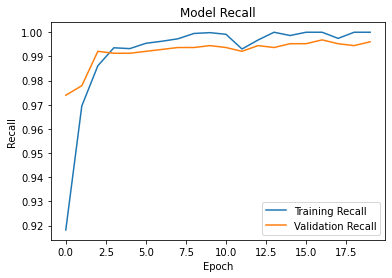

In [8]:
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])

plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Training Recall', 'Validation Recall'])

plt.show()

## **Precision Performance**

Precision evaluates the reliability of positive COVID-19 predictions by measuring how many predicted positive cases were truly positive.

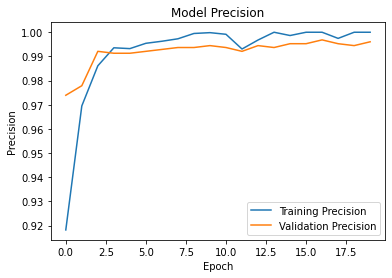

In [9]:
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])

plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Training Precision', 'Validation Precision'])

plt.show()

## **Accuracy Performance**

Accuracy measures overall prediction correctness across both classes.

Although useful, accuracy is treated as a supporting metric in this project because medical diagnosis prioritizes reducing missed positive cases over overall correctness.

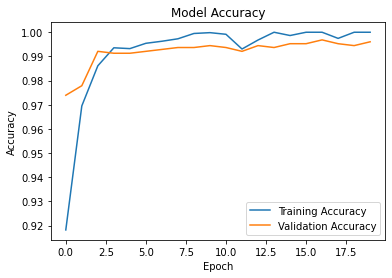

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

## **Loss Analysis**

Loss measures model error during training.

A decreasing loss trend indicates the model is learning meaningful patterns from the CT scan images and improving over time.

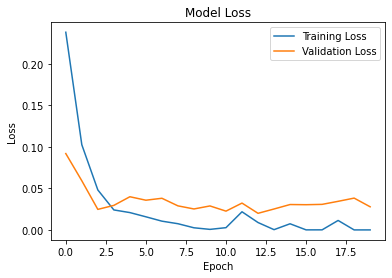

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

## **Model Evaluation on Test Data**

The trained model was evaluated on unseen test data to measure real-world performance using Recall, Precision, AUC, and Accuracy.

In [13]:
test_loss, test_recall, test_precision, test_auc, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Recall:", test_recall)
print("Test Precision:", test_precision)
print("Test AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

40/40 [==============================] - 1s 32ms/step - loss: 0.0273 - recall: 0.9968 - precision: 0.9968 - auc: 0.9976 - accuracy: 0.9968
Test Loss: 0.027348920702934265
Test Recall: 0.9968404173851013
Test Precision: 0.9968404173851013
Test AUC: 0.997599184513092
Test Accuracy: 0.9968404173851013


## **Test Performance Summary**

The model achieved:
- Recall: 99.68%
- Precision: 99.68%
- AUC: 99.76%
- Accuracy: 99.68%

The high recall indicates strong ability to correctly detect COVID-19 cases, making the model suitable for high-sensitivity medical screening.

## **Confusion Matrix Analysis**

The confusion matrix provides a breakdown of correct and incorrect predictions.

This helps identify false positives and false negatives, which are critical in assessing medical model risk.

40/40 [==============================] - 2s 29ms/step


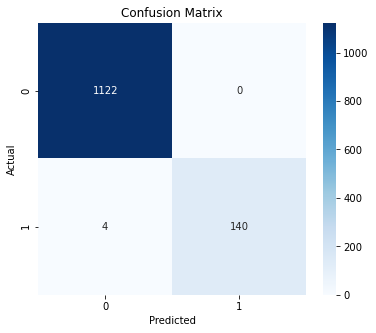

In [14]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## **Classification Report**

The classification report provides class-level Precision, Recall, and F1-score, offering a more detailed assessment of model performance across both categories.

In [15]:
print(classification_report(true_classes, pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1122
           1       1.00      0.97      0.99       144

    accuracy                           1.00      1266
   macro avg       1.00      0.99      0.99      1266
weighted avg       1.00      1.00      1.00      1266



## **Conclusion**

This project successfully developed a CNN model for automated COVID-19 detection using lung CT scan images.

The model demonstrated strong predictive performance, with Recall prioritized as the primary metric to minimize false negatives. This makes the approach suitable for supporting clinical screening and improving diagnostic efficiency.